In [2]:
# we will use this script to connect to a MySQL database and display our fraud dataset 
import mysql.connector
import pandas as pd
import numpy as np
# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",      
    user="root",
    password="susboi2213",
    database="fraud_data"
)

# Query data
query = "SELECT * FROM  paysim_transactions where type in ('TRANSFER', 'CASH_OUT');"
df = pd.read_sql(query, conn)

# Close connection
conn.close()

C:\Users\alyah\AppData\Local\Temp\ipykernel_13724\364049827.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [ ]:
# we used transactions for transfer and cash_out only
# as fraud is only reported in these two transaction types

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_mismatch_flag,overdraft_flag,drained_account_flag,dest_balance_mismatch_flag,high_amount_ratio_flag,hour_of_day,night_transaction_flag
0,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,0,0,1,1,1,1,1
1,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,0,0,1,1,1,1,1
2,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,1,1,1,1,1,1,1
3,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,1,1,1,1,1,1,1
4,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,1,1,1,1,1,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2770393 entries, 0 to 2770392
Data columns (total 18 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   step                        int64  
 1   type                        object 
 2   amount                      float64
 3   nameOrig                    object 
 4   oldbalanceOrg               float64
 5   newbalanceOrig              float64
 6   nameDest                    object 
 7   oldbalanceDest              float64
 8   newbalanceDest              float64
 9   isFraud                     int64  
 10  isFlaggedFraud              int64  
 11  balance_mismatch_flag       int64  
 12  overdraft_flag              int64  
 13  drained_account_flag        int64  
 14  dest_balance_mismatch_flag  int64  
 15  high_amount_ratio_flag      int64  
 16  hour_of_day                 int64  
 17  night_transaction_flag      int64  
dtypes: float64(5), int64(10), object(3)
memory usage: 380.5+ MB


In [5]:
# our data is successfully loaded from the MySQL database and displayed in the notebook
# we have only transfer and cash_out transactions since fraud happens only in these two types
# so our anomaly detection model will be focused on these two types of transactions only
# so i can tell what is normal behavior and what is anomalous behavior
# the model we will use is Isolation Forest 
# as its good for large datasets and high-dimensional data also its widely used for fraud detection tasks
# our data was cleaned and preprocessed 
# we will just take columns we want and drop rest 

features = df.drop(['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud', 'type', 'step'], axis=1)


In [6]:
features.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_mismatch_flag,overdraft_flag,drained_account_flag,dest_balance_mismatch_flag,high_amount_ratio_flag,hour_of_day,night_transaction_flag
0,181.00,181.0,0.0,0.0,0.00,0,0,1,1,1,1,1
1,181.00,181.0,0.0,21182.0,0.00,0,0,1,1,1,1,1
2,229133.94,15325.0,0.0,5083.0,51513.44,1,1,1,1,1,1,1
3,215310.30,705.0,0.0,22425.0,0.00,1,1,1,1,1,1,1
4,311685.89,10835.0,0.0,6267.0,2719172.89,1,1,1,1,1,1,1


In [7]:
features.duplicated().sum()

np.int64(36)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
# import our model
from sklearn.ensemble import IsolationForest


In [10]:
# now we will create and train our model
model = IsolationForest(n_estimators=100, random_state=42,n_jobs=-1)
model.fit(features)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [11]:
scores = model.decision_function(features)

In [12]:
scores

array([-0.17826717, -0.17787646, -0.10282022, ..., -0.23868257,
       -0.17653146, -0.19969436], shape=(2770393,))

In [13]:
# we have our anaomaly scores now 
# since we are going to combine these scores with other scores we will make and also test model against isfraud column to see if high scores correspond to fraud or not
# we will use minmaxscaler to scale scores between 0 and 1 for easier interpretation
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['anomaly_score']  = scaler.fit_transform(scores.reshape(-1, 1))

In [14]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_mismatch_flag,overdraft_flag,drained_account_flag,dest_balance_mismatch_flag,high_amount_ratio_flag,hour_of_day,night_transaction_flag,anomaly_score
0,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,0,0,1,1,1,1,1,0.265065
1,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,0,0,1,1,1,1,1,0.265901
2,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,1,1,1,1,1,1,1,0.426606
3,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,1,1,1,1,1,1,1,0.428082
4,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,1,1,1,1,1,1,1,0.420134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770388,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,0,0,1,0,1,23,0,0.420537
2770389,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,0,0,1,1,1,23,0,0.170032
2770390,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,0,0,1,1,1,23,0,0.135707
2770391,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,0,0,1,1,1,23,0,0.268781


In [15]:
# we will test how well our model performed by checking  anaomaly scores for fraudulent transactions
df.sort_values('anomaly_score', ascending=False).head(100)[['anomaly_score', 'isFraud']]



,anomaly_score,isFraud
1318825,1.000000,0
946825,1.000000,0
578610,1.000000,0
141381,1.000000,0
1316296,1.000000,0
...,...,...
1501423,0.999931,0
1316748,0.999931,0
2176456,0.999931,0
1822919,0.999931,0


In [16]:
# after scaling the scores are inverted where lower scores indicate higher likelihood of fraud
# so we will invert the scores also beacuse we will combine these scores with other scores later
df['anomaly_score'] = 1 - df['anomaly_score']

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

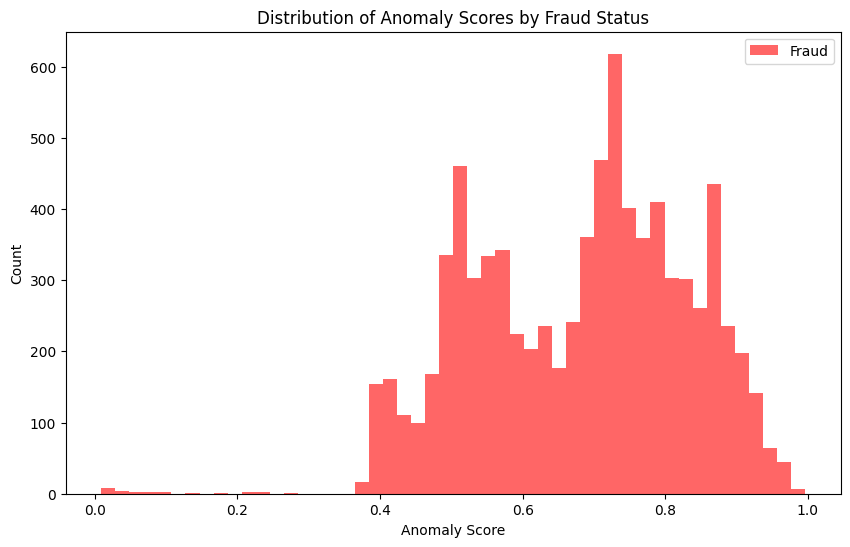

In [18]:
plt.figure(figsize=(10,6))
plt.hist(df[df['isFraud'] == 1]['anomaly_score'], bins=50, alpha=0.6, label='Fraud', color='red')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.title('Distribution of Anomaly Scores by Fraud Status')
plt.legend()
plt.show()


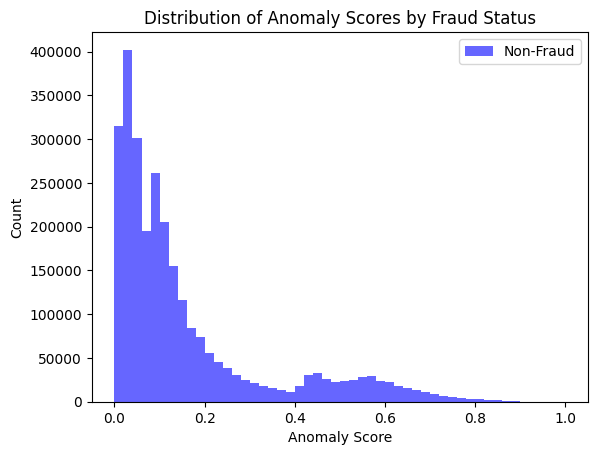

In [19]:
plt.hist(df[df['isFraud'] == 0]['anomaly_score'], bins=50, alpha=0.6, label='Non-Fraud', color='blue')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.title('Distribution of Anomaly Scores by Fraud Status')
plt.legend()
plt.show()

In [20]:
# from the histogram we can see that fraudulent transactions tend to have higher anomaly scores compared to non-fraudulent transactions
# to further evaluate the model we can calculate metrics like precision, recall,
# Create score buckets (e.g., deciles)

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(df['isFraud'], df['anomaly_score'])
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9639


In [21]:
threshold = df['anomaly_score'].quantile(0.99)
top_1_percent = df[df['anomaly_score'] >= threshold]
precision_top_1 = top_1_percent['isFraud'].mean()
print(f"Precision in Top 1%: {precision_top_1:.4f}")

Precision in Top 1%: 0.1235


In [22]:
top_1_percent.shape

(27704, 19)

In [23]:
recall_top_1 = top_1_percent['isFraud'].sum() / df['isFraud'].sum()
print(f"Recall in Top 1%: {recall_top_1:.4f}")

Recall in Top 1%: 0.4175


In [24]:
# from results we can see that our model is performing well
# our roc-auc score is so close to 1  which is excellent indicating good separability between fraud and non-fraud transaction
# for precision in top 1% of most anomalous transactions only 12% of thtese transactions are fraud which shows exterme class imbalance
# for recall in top 1% most anomalous transactions 41% of fruad is found in this top 1% while resting 59% fraud is spread across remaining 99% of transactions

# now we will start making our own flag scores to combine with anomaly scores 
# so we have a final overall fraud score for each transaction

flag_weights = {
    'balance_mismatch_flag': 0.32,
    'drained_account_flag': 0.23,
    'dest_balance_mismatch_flag': 0.18,
    'overdraft_flag': 0.12,
    'high_amount_ratio_flag': 0.10,
    'night_transaction_flag': 0.05
}

# Calculate weighted flag score for each transaction
df['flag_score'] = (
    df['balance_mismatch_flag'] * flag_weights['balance_mismatch_flag'] +
    df['drained_account_flag'] * flag_weights['drained_account_flag'] +
    df['dest_balance_mismatch_flag'] * flag_weights['dest_balance_mismatch_flag'] +
    df['overdraft_flag'] * flag_weights['overdraft_flag'] +
    df['high_amount_ratio_flag'] * flag_weights['high_amount_ratio_flag'] +
    df['night_transaction_flag'] * flag_weights['night_transaction_flag']
)


In [25]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_mismatch_flag,overdraft_flag,drained_account_flag,dest_balance_mismatch_flag,high_amount_ratio_flag,hour_of_day,night_transaction_flag,anomaly_score,flag_score
0,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,0,0,1,1,1,1,1,0.734935,0.56
1,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,0,0,1,1,1,1,1,0.734099,0.56
2,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,1,1,1,1,1,1,1,0.573394,1.00
3,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,1,1,1,1,1,1,1,0.571918,1.00
4,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,1,1,1,1,1,1,1,0.579866,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2770388,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,0,0,1,0,1,23,0,0.579463,0.33
2770389,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,0,0,1,1,1,23,0,0.829968,0.51
2770390,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,0,0,1,1,1,23,0,0.864293,0.51
2770391,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,0,0,1,1,1,23,0,0.731219,0.51


In [26]:
df['final_risk_score'] = 0.7 * df['anomaly_score'] + 0.3 * df['flag_score']

In [27]:
df[['flag_score', 'anomaly_score','final_risk_score']].head()

,flag_score,anomaly_score,final_risk_score
0,0.56,0.734935,0.682455
1,0.56,0.734099,0.681869
2,1.00,0.573394,0.701376
3,1.00,0.571918,0.700343
4,1.00,0.579866,0.705906


In [28]:
threshold = df['final_risk_score'].quantile(0.99)  # Top 1% risk

In [29]:
threshold

np.float64(0.7026580994879404)

In [30]:
df['predicted_fraud'] = (df['final_risk_score'] >= threshold).astype(int)

In [31]:
df['isFraud'].value_counts()

isFraud
0    2762196
1       8197
Name: count, dtype: int64

In [32]:
df['predicted_fraud'].value_counts()

predicted_fraud
0    2742689
1      27704
Name: count, dtype: int64

In [33]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score

cm = confusion_matrix(df['isFraud'], df['predicted_fraud'])
precision = precision_score(df['isFraud'], df['predicted_fraud'])
recall = recall_score(df['isFraud'], df['predicted_fraud'])
auc = roc_auc_score(df['isFraud'], df['final_risk_score'])

print("Confusion Matrix:\n", cm)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {auc:.4f}")

Confusion Matrix:
 [[2736322   25874]
 [   6367    1830]]
Precision: 0.0661
Recall: 0.2233
ROC-AUC: 0.9538


In [46]:
def evaluate_score(df, score_col, ks=(0.0005,0.001,0.003,0.005, 0.01, 0.02)):
    print(f"=== Evaluating {score_col} ===")
    # 1) Global AUC
    auc = roc_auc_score(df['isFraud'], df[score_col])
    print(f"ROC-AUC: {auc:.4f}")
    
    # 2) Precision/recall at different top-k%
    for k in ks:
        q = 1 - k  # e.g. k=0.01 -> q=0.99
        thr = df[score_col].quantile(q)
        top_k = df[df[score_col] >= thr]
        
        precision_k = top_k['isFraud'].mean()
        recall_k = top_k['isFraud'].sum() / df['isFraud'].sum()
        
        print(f"Top {k*100:.2f}% (threshold={thr:.4f}): "
              f"precision={precision_k:.4f}, recall={recall_k:.4f}, "
              f"n={len(top_k)}")
    print()

evaluate_score(df, 'anomaly_score')
evaluate_score(df, 'final_risk_score')

=== Evaluating anomaly_score ===
ROC-AUC: 0.9639
Top 0.05% (threshold=0.8787): precision=0.4899, recall=0.0828, n=1386
Top 0.10% (threshold=0.8564): precision=0.4197, recall=0.1419, n=2771
Top 0.30% (threshold=0.8112): precision=0.2162, recall=0.2192, n=8313
Top 0.50% (threshold=0.7805): precision=0.1712, recall=0.2894, n=13852
Top 1.00% (threshold=0.7305): precision=0.1235, recall=0.4175, n=27704
Top 2.00% (threshold=0.6772): precision=0.0838, recall=0.5667, n=55408

=== Evaluating final_risk_score ===
ROC-AUC: 0.9538
Top 0.05% (threshold=0.8410): precision=0.0022, recall=0.0004, n=1389
Top 0.10% (threshold=0.8156): precision=0.0141, recall=0.0048, n=2771
Top 0.30% (threshold=0.7682): precision=0.0741, recall=0.0751, n=8312
Top 0.50% (threshold=0.7414): precision=0.0653, recall=0.1104, n=13852
Top 1.00% (threshold=0.7027): precision=0.0661, recall=0.2233, n=27704
Top 2.00% (threshold=0.6511): precision=0.0653, recall=0.4416, n=55408



In [ ]:
# we found out that combining the anomaly scores from Isolation Forest with our custom flag weights significantly  lowered our scores
# as these weights were from same columns  ml model already trained on so it didnt add any new information
# also made final score not optimal this was an important learning experience and an experiment to try
# so now we will just use anomaly scores from Isolation Forest as our final fraud score
# we will use thresholds to take action on transactions based on business needs
# we did analysis on precision and recall at various thresholds to help decide these thresholds

# We define three decision bands based on the Isolation Forest anomaly_score:
#
# 1) Block band (very high risk)
#    - Score range: anomaly_score >= 0.8564
#    - Share of transactions: about the top 0.10% of all transactions
#    - Approximate count: ~2,771 transactions in our sample
#    - Fraud rate (precision): ~41.97% of these transactions are actually fraud
#    - Recall (fraud caught): this small band alone captures ~14.19% of all frauds
#    - Risk uplift vs average: overall fraud rate is ~0.3%, so this band is
#      roughly 140x more likely to be fraud than a random transaction
#    - Rationale: this is an extremely high‑risk group with tiny volume,
#      so it is suitable for auto‑block / strong hold decisions.
#
# 2) Review band (high risk)
#    - Score range: 0.7805 <= anomaly_score < 0.8564
#    - Share of transactions: from the top 0.10% to the top 0.50%
#      (i.e. about 0.40% of all transactions)
#    - Approximate count: ~11,081 transactions in our sample
#    - Fraud rate: ~10.9% of these transactions are fraud
#    - Risk uplift vs average: about 36x higher fraud rate than the ~0.3% baseline
#    - Rationale: this band is still very concentrated in fraud but larger
#      than the block band, so it is appropriate for a manual review queue.
#
# 3) Allow band (low risk)
#    - Score range: anomaly_score < 0.7805
#    - Share of transactions: about 99.50% of all transactions
#    - Fraud rate: close to the very low baseline (~0.3%)
#    - Rationale: these transactions are much less risky, so we treat them
#      as auto‑approved, with only standard background monitoring.
#
# Overall effect (block + review together)
#    - Total volume: only the top 0.50% of transactions (block + review bands)
#    - Total recall: these bands together capture ~28.94% of all fraud cases
#    - Total precision in top 0.50%: ~17.12% of transactions in this top 0.50%
#      are fraud, which is tens of times higher than the baseline rate
#    - Interpretation: by focusing human and blocking effort on just 0.5% of
#      the traffic, we concentrate a large share of fraud into a very small
#      portion of transactions, which is realistic for a practical fraud system.

In [36]:
df.drop(columns=['predicted_fraud'], inplace=True)

In [47]:
thr_block = 0.8564   # Block: score >= 0.8564
thr_review = 0.7805  # Review: 0.7805 <= score < 0.8564

def decision_from_score(score):
    if score >= thr_block:
        return 'block'
    elif score >= thr_review:
        return 'review'
    else:
        return 'allow'

df['decision'] = df['anomaly_score'].apply(decision_from_score)

In [48]:
print(df['decision'].value_counts())

decision
allow     2756534
review      11088
block        2771
Name: count, dtype: int64


In [50]:
# How many fraud / non-fraud in each band
decision_table = pd.crosstab(df['decision'], df['isFraud'], margins=True)
print(decision_table)

# Add fraud rate per band (isFraud = 1 column assumed)
decision_table_rates = decision_table.copy()
decision_table_rates['fraud_rate'] = decision_table_rates[1] *100 / decision_table_rates['All']
print("\nFraud rate per band:")
print(decision_table_rates[['All', 1, 'fraud_rate']])

isFraud         0     1      All
decision                        
allow     2750710  5824  2756534
block        1608  1163     2771
review       9878  1210    11088
All       2762196  8197  2770393

Fraud rate per band:
isFraud       All     1  fraud_rate
decision                           
allow     2756534  5824    0.211280
block        2771  1163   41.970408
review      11088  1210   10.912698
All       2770393  8197    0.295879


In [ ]:
# Predicted fraud if we decide block or review; allow = non-fraud
df['predicted_fraud_band'] = df['decision'].isin(['block', 'review']).astype(int)

cm = confusion_matrix(df['isFraud'], df['predicted_fraud_band'])
precision = precision_score(df['isFraud'], df['predicted_fraud_band'])
recall = recall_score(df['isFraud'], df['predicted_fraud_band'])

print("Confusion matrix (rows=actual, cols=predicted):\n", cm)
print(f"Precision (Block+Review as fraud): {precision:.4f}")
print(f"Recall    (Block+Review as fraud): {recall:.4f}")

Confusion matrix (rows=actual, cols=predicted):
 [[2750710   11486]
 [   5824    2373]]
Precision (Block+Review as fraud): 0.1712
Recall    (Block+Review as fraud): 0.2895


In [52]:
decision_table = df[['isFraud', 'decision']]

In [ ]:
conn = mysql.connector.connect(
    host="localhost",      
    user="root",
    password="susboi2213",
    database="fraud_data"
)
cursor = conn.cursor()

cursor.execute("""
    CREATE TABLE fraud_detection_decisions (
        isFraud TINYINT(1),
        decision VARCHAR(20)
    )
""")

insert_sql = "INSERT INTO fraud_detection_decisions (isFraud, decision) VALUES (%s, %s)"
data = list(decision_table.itertuples(index=False, name=None))
cursor.executemany(insert_sql, data)

conn.commit()
cursor.close()
conn.close()
# save the dataframe with decisions to a new table in MySQL database
